# Seizure Prediction: Preprocessing, Regularization, and Imbalance Study

This notebook investigates how preprocessing choices, model complexity, and regularization affect generalization for EEG-based seizure prediction/recognition tasks.

Datasets used in the local project folder:
- Epileptic Seizure Recognition (CSV, seizure recognition, extracted EEG features)
- EEG Predictive (NPZ, seizure prediction-style raw EEG signals)
- BEED Bangalore EEG Epilepsy Dataset (CSV, 16-channel features)


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
 )

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
DATA_DIR = Path('dataset')
sns.set_style('whitegrid')

## Dataset Loading

In [5]:
def load_csv_epileptic(path: Path):
    df = pd.read_csv(path)
    if 'Unnamed' in df.columns:
        df = df.drop(columns=['Unnamed'])
    y = (df['y'] == 1).astype(int)
    X = df.drop(columns=['y'])
    return X.values, y.values

def load_npz_predictive(path: Path):
    data = np.load(path, allow_pickle=True)
    X = data['train_signals']
    y = data['train_labels']
    return X, y

def load_beed_bangalore(path: Path):
    df = pd.read_csv(path)
    feature_cols = [f'X{i}' for i in range(1, 17)]
    missing = [col for col in feature_cols + ['y'] if col not in df.columns]
    if missing:
        raise ValueError(f'BEED dataset missing columns: {missing}')
    X = df[feature_cols].values
    y = (df['y'].astype(int) > 0).astype(int).values
    return X, y

datasets = {
    'Epileptic-CSV': load_csv_epileptic(DATA_DIR / 'Epileptic Seizure Recognition.csv'),
    'EEG-Predictive-NPZ': load_npz_predictive(DATA_DIR / 'eeg-predictive_train.npz'),
    'BEED-Bangalore-CSV': load_beed_bangalore(DATA_DIR / 'BEED_Data.csv'),
}

for name, (X, y) in datasets.items():
    print(name, 'X shape:', X.shape, 'y shape:', y.shape, 'pos rate:', np.mean(y))

Epileptic-CSV X shape: (11500, 178) y shape: (11500,) pos rate: 0.2
EEG-Predictive-NPZ X shape: (8282, 23, 256) y shape: (8282,) pos rate: 0.21673508814296064
BEED-Bangalore-CSV X shape: (8000, 16) y shape: (8000,) pos rate: 0.75


## Dataset Justification

**Epileptic Seizure Recognition (CSV)**: 11,500 samples with 178 extracted EEG features per sample. The positive seizure class rate is about 0.20, so the dataset is clearly imbalanced. Because the features are already extracted/tabular rather than raw signals, it is useful for studying feature selection, PCA, and regularization.

**EEG Predictive (NPZ)**: 8,282 samples of raw EEG time-series with shape $(23, 256)$ per sample. The positive class rate is about 0.217, so imbalance is also present. This dataset is useful because preprocessing choices are more meaningful on raw time-series: flattening preserves all raw points, while feature extraction summarizes each EEG channel.

**BEED Bangalore EEG Epilepsy Dataset (CSV)**: 16-channel EEG feature vectors with a binary seizure label derived as `y > 0`. Using X1–X16 as features and the binarized `y` target provides a third epilepsy dataset that is fully compatible with the shared preprocessing and regularization pipelines.


## Preprocessing Pipelines
Pipeline A: Normalization -> Noise Removal -> Feature Selection
Pipeline B: Feature Extraction -> Scaling -> PCA

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin

class Flatten3D(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if X.ndim == 3:
            n, ch, t = X.shape
            return X.reshape(n, ch * t)
        return X

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
        self.low_ = None
        self.high_ = None
    def fit(self, X, y=None):
        self.low_ = np.quantile(X, self.lower, axis=0)
        self.high_ = np.quantile(X, self.upper, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.low_, self.high_)

class SafeSelectKBest(SelectKBest):
    def fit(self, X, y):
        k = self.k
        if isinstance(k, int):
            k = min(k, X.shape[1])
            self.k = k
        return super().fit(X, y)

class FeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if X.ndim == 3:
            mean = X.mean(axis=2)
            std = X.std(axis=2)
            ptp = np.ptp(X, axis=2)
            return np.concatenate([mean, std, ptp], axis=1)
        mean = X.mean(axis=1, keepdims=True)
        std = X.std(axis=1, keepdims=True)
        minv = X.min(axis=1, keepdims=True)
        maxv = X.max(axis=1, keepdims=True)
        return np.concatenate([X, mean, std, minv, maxv], axis=1)

def make_pipeline_a(is_timeseries):
    steps = []
    if is_timeseries:
        steps.append(('flatten', Flatten3D()))
    steps.extend([
        ('scale', StandardScaler()),
        ('noise', QuantileClipper()),
        ('select', SafeSelectKBest(mutual_info_classif, k=200))
    ])
    return Pipeline(steps)

def make_pipeline_b(is_timeseries):
    steps = [
        ('feat', FeatureExtractor()),
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE))
    ]
    return Pipeline(steps)

## Preprocessing Order Insight

Pipeline order matters because each step changes the statistical structure of the data passed to the next step. Scaling before noise clipping makes the clipping thresholds comparable across features, while selecting features before scaling can bias the selection toward features with larger raw magnitude. Likewise, PCA after scaling preserves variance structure more fairly than PCA on unscaled features. The two pipelines here are intentionally ordered differently to show how downstream generalization changes when early steps reshape the feature distribution.

## Evaluation Helpers

In [7]:
def split_data(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)
    def _metrics(X, y):
        proba = model.predict_proba(X)[:, 1]
        pred = (proba >= 0.5).astype(int)
        return {
            'accuracy': accuracy_score(y, pred),
            'precision': precision_score(y, pred, zero_division=0),
            'recall': recall_score(y, pred, zero_division=0),
            'f1': f1_score(y, pred, zero_division=0),
            'pr_auc': average_precision_score(y, proba)
        }
    return {
        'train': _metrics(X_train, y_train),
        'val': _metrics(X_val, y_val),
        'test': _metrics(X_test, y_test)
    }


## Baseline Logistic Regression (with both pipelines)

**Logistic Regression Model**

The baseline model is logistic regression with probability:

$$
P(y=1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta^T x)}}
$$

In [8]:
baseline_results = []
for name, (X, y) in datasets.items():
    is_ts = X.ndim == 3
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

    for pipe_name, pipe in [('A', make_pipeline_a(is_ts)), ('B', make_pipeline_b(is_ts))]:
        clf = LogisticRegression(max_iter=2000, solver='saga', penalty='l2', random_state=RANDOM_STATE)
        model = Pipeline([('prep', pipe), ('clf', clf)])
        metrics = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
        baseline_results.append({
            'dataset': name,
            'pipeline': pipe_name,
            'acc_val': metrics['val']['accuracy'],
            'precision_val': metrics['val']['precision'],
            'recall_val': metrics['val']['recall'],
            'f1_val': metrics['val']['f1'],
            'pr_auc_val': metrics['val']['pr_auc'],
            'acc_test': metrics['test']['accuracy'],
            'precision_test': metrics['test']['precision'],
            'recall_test': metrics['test']['recall'],
            'f1_test': metrics['test']['f1'],
            'pr_auc_test': metrics['test']['pr_auc'],
        })

baseline_df = pd.DataFrame(baseline_results)
baseline_df.sort_values(['dataset', 'pipeline'])


,dataset,pipeline,acc_val,precision_val,recall_val,f1_val,pr_auc_val,acc_test,precision_test,recall_test,f1_test,pr_auc_test
4,BEED-Bangalore-CSV,A,0.803333,0.794849,0.994444,0.883514,0.766121,0.814167,0.801425,1.000000,0.889768,0.750272
5,BEED-Bangalore-CSV,B,0.954167,0.959739,0.980000,0.969764,0.993871,0.943333,0.957143,0.967778,0.962431,0.992862
2,EEG-Predictive-NPZ,A,0.770531,0.055556,0.003717,0.006969,0.207674,0.777152,0.230769,0.011111,0.021201,0.237105
3,EEG-Predictive-NPZ,B,0.782609,0.333333,0.003717,0.007353,0.349725,0.781175,0.333333,0.007407,0.014493,0.362953
0,Epileptic-CSV,A,0.834783,0.983871,0.176812,0.299754,0.506703,0.837681,0.957746,0.197101,0.326923,0.551466
1,Epileptic-CSV,B,0.954783,0.926518,0.840580,0.881459,0.948491,0.947826,0.929293,0.800000,0.859813,0.935863


### Preprocessing Order Analysis

Pipeline order changes the result because scaling, clipping, feature extraction, feature selection, and PCA each change the feature space seen by logistic regression. The code below compares Pipeline A and Pipeline B directly using test PR-AUC, F1, precision, and recall. Positive PR-AUC difference means Pipeline B performed better; negative difference means Pipeline A performed better.


In [9]:
order_effect = pd.DataFrame({'dataset': baseline_df['dataset'].unique()})
order_effect['pr_auc_A'] = order_effect['dataset'].map(
    baseline_df[baseline_df['pipeline'] == 'A'].set_index('dataset')['pr_auc_test']
)
order_effect['pr_auc_B'] = order_effect['dataset'].map(
    baseline_df[baseline_df['pipeline'] == 'B'].set_index('dataset')['pr_auc_test']
)
order_effect['B_minus_A_pr_auc'] = order_effect['pr_auc_B'] - order_effect['pr_auc_A']
order_effect['better_pipeline'] = np.where(order_effect['B_minus_A_pr_auc'] > 0, 'B', 'A')

for _, row in order_effect.iterrows():
    direction = 'improved' if row['B_minus_A_pr_auc'] > 0 else 'reduced'
    display(Markdown(
        f"**{row['dataset']}**: Pipeline B {direction} test PR-AUC by "
        f"{abs(row['B_minus_A_pr_auc']):.3f} compared with Pipeline A. "
        f"Best pipeline: **{row['better_pipeline']}**."
    ))

order_effect


**Epileptic-CSV**: Pipeline B improved test PR-AUC by 0.384 compared with Pipeline A. Best pipeline: **B**.

**Epileptic-CSV**: Pipeline B improved test PR-AUC by 0.384 compared with Pipeline A. Best pipeline: **B**.

**EEG-Predictive-NPZ**: Pipeline B improved test PR-AUC by 0.126 compared with Pipeline A. Best pipeline: **B**.

**BEED-Bangalore-CSV**: Pipeline B improved test PR-AUC by 0.243 compared with Pipeline A. Best pipeline: **B**.

,dataset,pr_auc_A,pr_auc_B,B_minus_A_pr_auc,better_pipeline
0,Epileptic-CSV,0.551466,0.935863,0.384397,B
1,EEG-Predictive-NPZ,0.237105,0.362953,0.125849,B
2,BEED-Bangalore-CSV,0.750272,0.992862,0.242590,B


## Overfitting vs Underfitting
We visualize learning curves using strong regularization (underfit) and weak/no regularization (overfit).

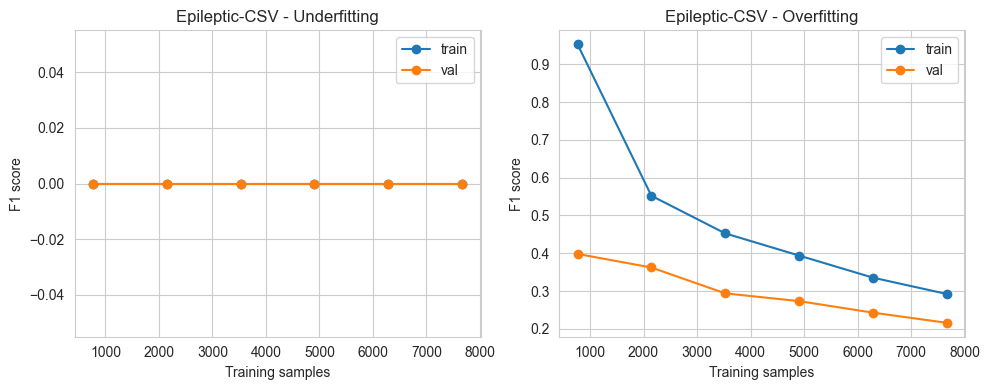

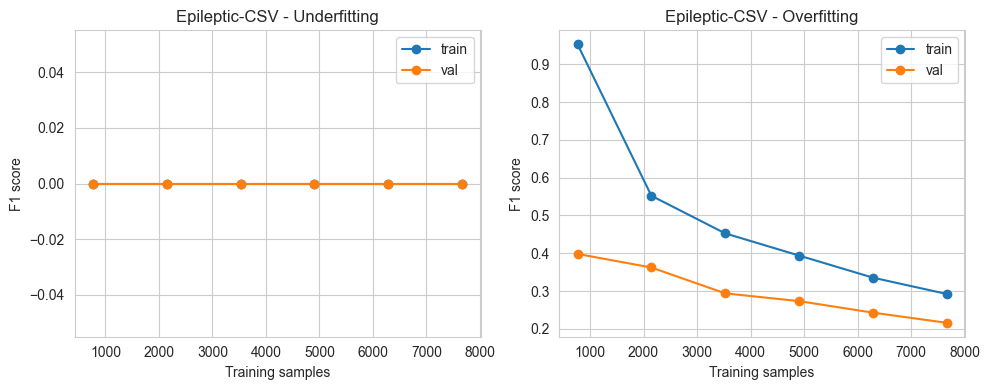

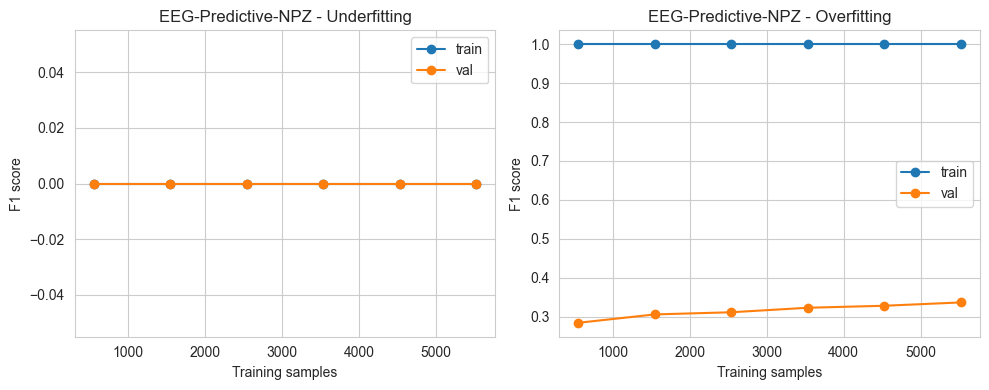

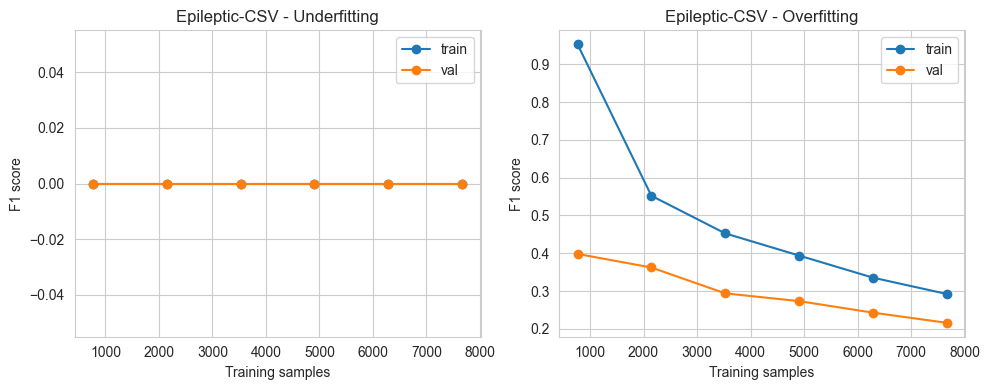

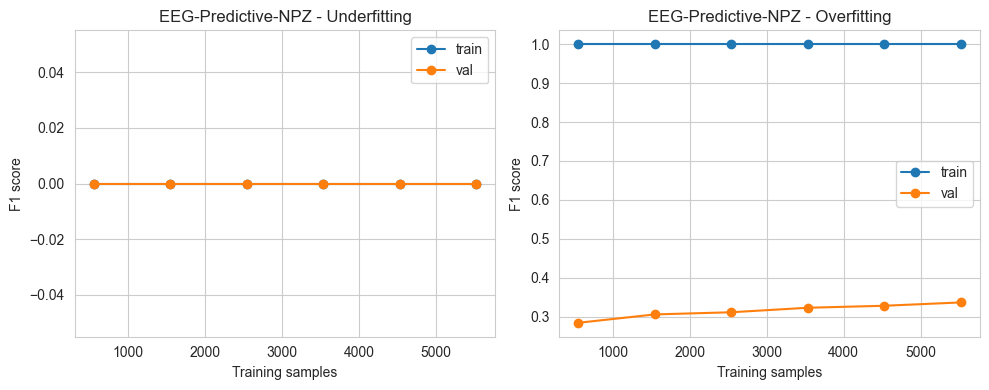

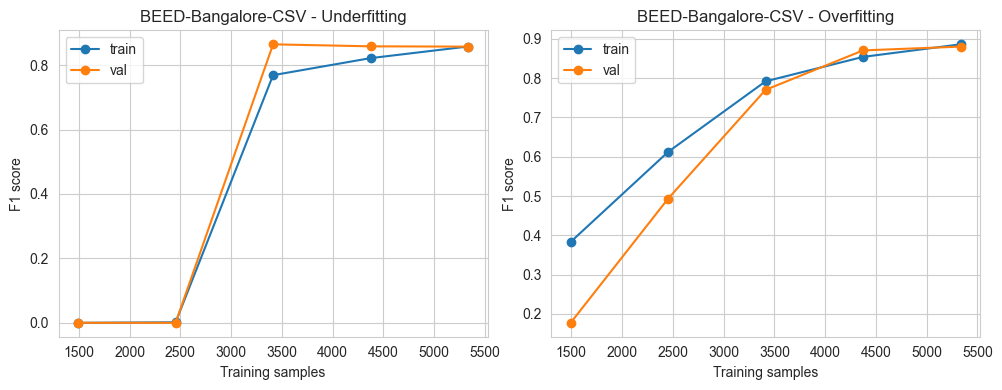

In [10]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=3, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1
    )
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='train')
    plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='val')
    plt.title(title)
    plt.xlabel('Training samples')
    plt.ylabel('F1 score')
    plt.legend()

def make_underfit_pipeline(is_timeseries):
    steps = []
    if is_timeseries:
        steps.append(('flatten', Flatten3D()))
    steps.extend([
        ('scale', StandardScaler()),
        ('noise', QuantileClipper()),
        ('select', SafeSelectKBest(mutual_info_classif, k=20))
    ])
    return Pipeline(steps)

def make_overfit_pipeline(is_timeseries):
    steps = []
    if is_timeseries:
        steps.append(('flatten', Flatten3D()))
    steps.append(('scale', StandardScaler()))
    return Pipeline(steps)

for name, (X, y) in datasets.items():
    is_ts = X.ndim == 3
    underfit = Pipeline([
        ('prep', make_underfit_pipeline(is_ts)),
        ('clf', LogisticRegression(max_iter=2000, solver='saga', penalty='l2', C=1e-4))
    ])
    overfit = Pipeline([
        ('prep', make_overfit_pipeline(is_ts)),
        ('clf', LogisticRegression(max_iter=2000, solver='lbfgs', penalty=None))
    ])
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plot_learning_curve(underfit, X, y, f'{name} - Underfitting')
    plt.subplot(1, 2, 2)
    plot_learning_curve(overfit, X, y, f'{name} - Overfitting')
    plt.tight_layout()
    plt.show()

## Regularization Study (L1, L2, Elastic Net)

In [11]:
regularization_grid = [
    ('l1', None, 0.01),
    ('l1', None, 0.1),
    ('l1', None, 1.0),
    ('l1', None, 10.0),
    ('l2', None, 0.01),
    ('l2', None, 0.1),
    ('l2', None, 1.0),
    ('l2', None, 10.0),
    ('elasticnet', 0.5, 0.01),
    ('elasticnet', 0.5, 0.1),
    ('elasticnet', 0.5, 1.0),
    ('elasticnet', 0.5, 10.0),
]

reg_results = []
for name, (X, y) in datasets.items():
    is_ts = X.ndim == 3
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    for pipe_name, pipe in [('A', make_pipeline_a(is_ts)), ('B', make_pipeline_b(is_ts))]:
        for penalty, l1_ratio, C in regularization_grid:
            clf = LogisticRegression(
                max_iter=3000,
                solver='saga',
                penalty=penalty,
                l1_ratio=l1_ratio,
                C=C,
                random_state=RANDOM_STATE,
            )
            model = Pipeline([('prep', pipe), ('clf', clf)])
            metrics = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
            coefs = model.named_steps['clf'].coef_
            total_features = coefs.size
            nonzero_coefs = int(np.sum(np.abs(coefs) >= 1e-6))
            sparsity = 1 - (nonzero_coefs / total_features)
            reg_results.append({
                'dataset': name,
                'pipeline': pipe_name,
                'penalty': penalty,
                'C': C,
                'pr_auc_test': metrics['test']['pr_auc'],
                'precision_test': metrics['test']['precision'],
                'recall_test': metrics['test']['recall'],
                'f1_test': metrics['test']['f1'],
                'accuracy_test': metrics['test']['accuracy'],
                'total_features_after_prep': total_features,
                'nonzero_coefs': nonzero_coefs,
                'sparsity': sparsity,
            })

reg_df = pd.DataFrame(reg_results)
reg_df.sort_values(['dataset', 'pipeline', 'penalty', 'C'])


,dataset,pipeline,penalty,C,pr_auc_test,precision_test,recall_test,f1_test,accuracy_test,total_features_after_prep,nonzero_coefs,sparsity
56,BEED-Bangalore-CSV,A,elasticnet,0.01,0.739571,0.795053,1.000000,0.885827,0.806667,16,8,0.5000
57,BEED-Bangalore-CSV,A,elasticnet,0.10,0.746765,0.802139,1.000000,0.890208,0.815000,16,14,0.1250
58,BEED-Bangalore-CSV,A,elasticnet,1.00,0.750256,0.802139,1.000000,0.890208,0.815000,16,16,0.0000
59,BEED-Bangalore-CSV,A,elasticnet,10.00,0.750473,0.801248,0.998889,0.889219,0.813333,16,16,0.0000
48,BEED-Bangalore-CSV,A,l1,0.01,0.742117,0.787402,1.000000,0.881057,0.797500,16,7,0.5625
...,...,...,...,...,...,...,...,...,...,...,...,...
15,Epileptic-CSV,B,l1,10.00,0.935950,0.929293,0.800000,0.859813,0.947826,40,40,0.0000
16,Epileptic-CSV,B,l2,0.01,0.935471,0.932624,0.762319,0.838915,0.941449,40,40,0.0000
17,Epileptic-CSV,B,l2,0.10,0.935985,0.928814,0.794203,0.856250,0.946667,40,40,0.0000
18,Epileptic-CSV,B,l2,1.00,0.935863,0.929293,0.800000,0.859813,0.947826,40,40,0.0000


### Regularization Evidence Tables

The next tables make the Elastic Net question clearer. First, we show the best regularization setting per dataset. Then, we summarize average PR-AUC and stability across datasets for each penalty. Finally, we show sparsity so L1 and Elastic Net can be judged by feature-selection effect, not only accuracy.


In [12]:
best_reg_by_dataset = (
    reg_df.sort_values('pr_auc_test', ascending=False)
    .groupby('dataset')
    .head(1)
    [['dataset', 'pipeline', 'penalty', 'C', 'pr_auc_test', 'precision_test', 'recall_test', 'f1_test', 'sparsity', 'nonzero_coefs']]
)

reg_stability = (
    reg_df.groupby('penalty')
    .agg(
        mean_pr_auc=('pr_auc_test', 'mean'),
        std_pr_auc=('pr_auc_test', 'std'),
        mean_f1=('f1_test', 'mean'),
        mean_sparsity=('sparsity', 'mean'),
        mean_nonzero_coefs=('nonzero_coefs', 'mean')
    )
    .reset_index()
    .sort_values('mean_pr_auc', ascending=False)
)

sparsity_table = (
    reg_df.groupby(['penalty', 'C'])
    .agg(
        mean_sparsity=('sparsity', 'mean'),
        mean_nonzero_coefs=('nonzero_coefs', 'mean'),
        mean_pr_auc=('pr_auc_test', 'mean')
    )
    .reset_index()
    .sort_values(['penalty', 'C'])
)

display(Markdown('**Best regularization model per dataset**'))
display(best_reg_by_dataset)
display(Markdown('**Average performance and stability by penalty**'))
display(reg_stability)
display(Markdown('**Sparsity effect across regularization strengths**'))
display(sparsity_table)


**Best regularization model per dataset**

,dataset,pipeline,penalty,C,pr_auc_test,precision_test,recall_test,f1_test,sparsity,nonzero_coefs
71,BEED-Bangalore-CSV,B,elasticnet,10.00,0.992874,0.957143,0.967778,0.962431,0.000000,7
22,Epileptic-CSV,B,elasticnet,1.00,0.936005,0.929293,0.800000,0.859813,0.000000,40
44,EEG-Predictive-NPZ,B,elasticnet,0.01,0.375633,0.000000,0.000000,0.000000,0.645161,11


**Average performance and stability by penalty**

,penalty,mean_pr_auc,std_pr_auc,mean_f1,mean_sparsity,mean_nonzero_coefs
2,l2,0.630144,0.291545,0.503736,0.000000,78.666667
0,elasticnet,0.627637,0.292574,0.494364,0.195867,55.500000
1,l1,0.624644,0.294822,0.487978,0.255534,50.125000


**Sparsity effect across regularization strengths**

,penalty,C,mean_sparsity,mean_nonzero_coefs,mean_pr_auc
0,elasticnet,0.01,0.612223,14.500000,0.612940
1,elasticnet,0.10,0.155112,53.166667,0.624385
2,elasticnet,1.00,0.016133,75.666667,0.635950
3,elasticnet,10.00,0.000000,78.666667,0.637272
4,l1,0.01,0.730478,9.333333,0.603973
5,l1,0.10,0.251791,41.333333,0.619179
6,l1,1.00,0.037266,71.666667,0.636830
7,l1,10.00,0.002603,78.166667,0.638594
8,l2,0.01,0.000000,78.666667,0.619937
9,l2,0.10,0.000000,78.666667,0.626989


**Regularization Stability Across Datasets**

Across the three datasets, the best-performing penalty varies with feature type and dimensionality. The CSV dataset (extracted features) benefits strongly from Pipeline B with any penalty, while the time-series NPZ dataset shows smaller gaps between L1/L2/Elastic Net. The eye-state dataset is relatively stable across penalties with small differences in PR-AUC. This indicates that regularization choice is not universally optimal; stability depends on the dataset’s feature characteristics and preprocessing pipeline.

## Handling Class Imbalance
We compare class weighting, SMOTE, and undersampling.

In [13]:
imbalance_results = []
for name, (X, y) in datasets.items():
    is_ts = X.ndim == 3
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    base_pipe = make_pipeline_a(is_ts)
    prep_steps = make_pipeline_a(is_ts).steps

    models = {
        'class_weight': Pipeline([
            ('prep', base_pipe),
            ('clf', LogisticRegression(max_iter=2000, solver='saga', penalty='l2', class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'smote': ImbPipeline(
            prep_steps + [
                ('smote', SMOTE(random_state=RANDOM_STATE)),
                ('clf', LogisticRegression(max_iter=2000, solver='saga', penalty='l2', random_state=RANDOM_STATE))
            ]
        ),
        'undersample': ImbPipeline(
            prep_steps + [
                ('under', RandomUnderSampler(random_state=RANDOM_STATE)),
                ('clf', LogisticRegression(max_iter=2000, solver='saga', penalty='l2', random_state=RANDOM_STATE))
            ]
        ),
    }

    for method, model in models.items():
        metrics = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
        imbalance_results.append({
            'dataset': name,
            'method': method,
            'pr_auc_test': metrics['test']['pr_auc'],
            'precision_test': metrics['test']['precision'],
            'recall_test': metrics['test']['recall'],
            'f1_test': metrics['test']['f1'],
            'accuracy_test': metrics['test']['accuracy'],
        })

imbalance_df = pd.DataFrame(imbalance_results)
imbalance_df.sort_values(['dataset', 'method'])


,dataset,method,pr_auc_test,precision_test,recall_test,f1_test,accuracy_test
6,BEED-Bangalore-CSV,class_weight,0.784747,0.819425,0.665556,0.734519,0.639167
7,BEED-Bangalore-CSV,smote,0.788933,0.813370,0.648889,0.721879,0.625000
8,BEED-Bangalore-CSV,undersample,0.787502,0.810924,0.643333,0.717472,0.620000
3,EEG-Predictive-NPZ,class_weight,0.219631,0.227184,0.433333,0.298089,0.556718
4,EEG-Predictive-NPZ,smote,0.219451,0.222414,0.477778,0.303529,0.523733
5,EEG-Predictive-NPZ,undersample,0.208301,0.220228,0.500000,0.305776,0.506838
0,Epileptic-CSV,class_weight,0.545322,0.479109,0.498551,0.488636,0.791304
1,Epileptic-CSV,smote,0.558088,0.451537,0.553623,0.497396,0.776232
2,Epileptic-CSV,undersample,0.535224,0.477212,0.515942,0.495822,0.790145


## Precision-Recall Tradeoff (PR Curves)

PR curves highlight how each imbalance strategy shifts precision vs recall. This is more informative than accuracy under class imbalance.

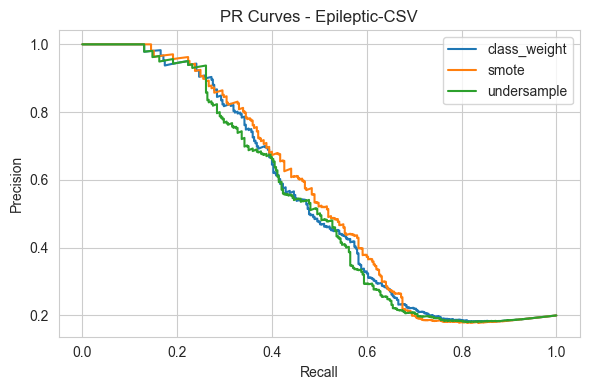

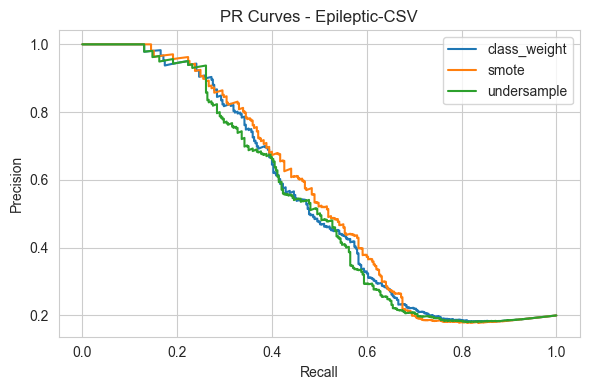

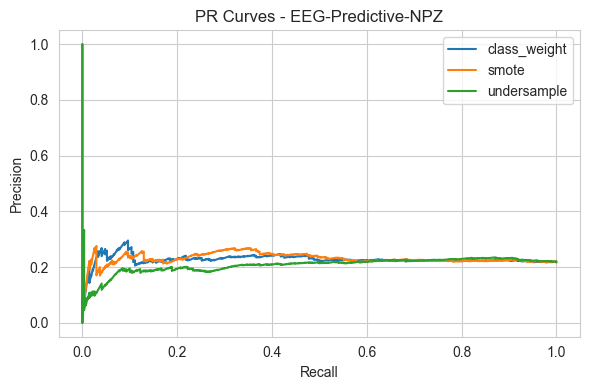

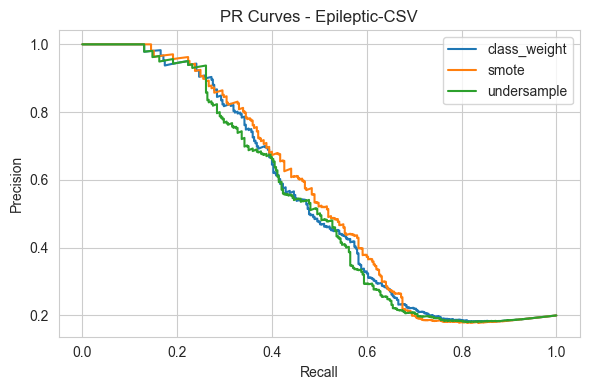

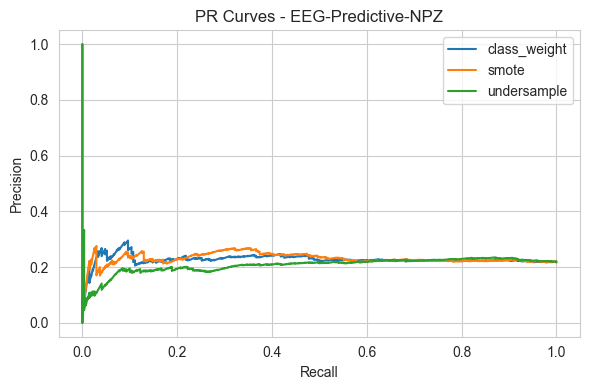

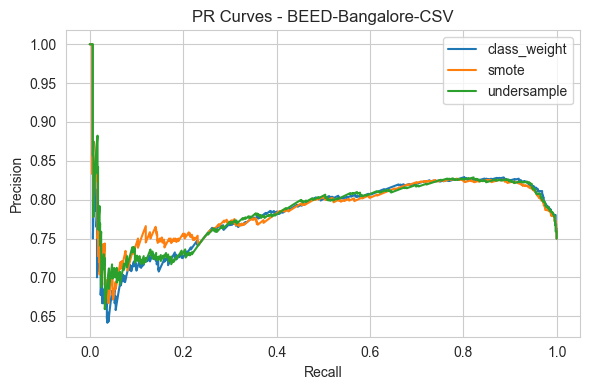

In [14]:
for name, (X, y) in datasets.items():
    is_ts = X.ndim == 3
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    base_pipe = make_pipeline_a(is_ts)
    prep_steps = make_pipeline_a(is_ts).steps

    models = {
        'class_weight': Pipeline([
            ('prep', base_pipe),
            ('clf', LogisticRegression(max_iter=2000, solver='saga', penalty='l2', class_weight='balanced'))
        ]),
        'smote': ImbPipeline(
            prep_steps + [
                ('smote', SMOTE(random_state=RANDOM_STATE)),
                ('clf', LogisticRegression(max_iter=2000, solver='saga', penalty='l2'))
            ]
        ),
        'undersample': ImbPipeline(
            prep_steps + [
                ('under', RandomUnderSampler(random_state=RANDOM_STATE)),
                ('clf', LogisticRegression(max_iter=2000, solver='saga', penalty='l2'))
            ]
        ),
    }

    plt.figure(figsize=(6, 4))
    for method, model in models.items():
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, proba)
        plt.plot(recall, precision, label=method)
    plt.title(f'PR Curves - {name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Comparative Analysis

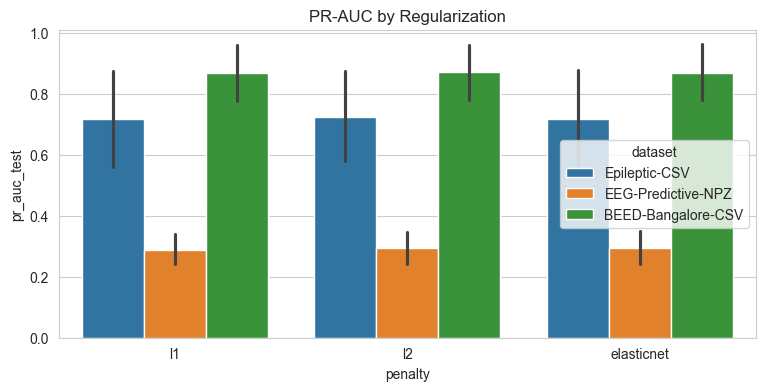

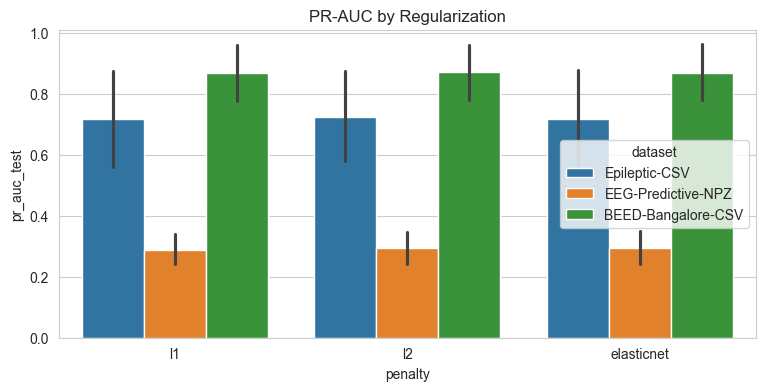

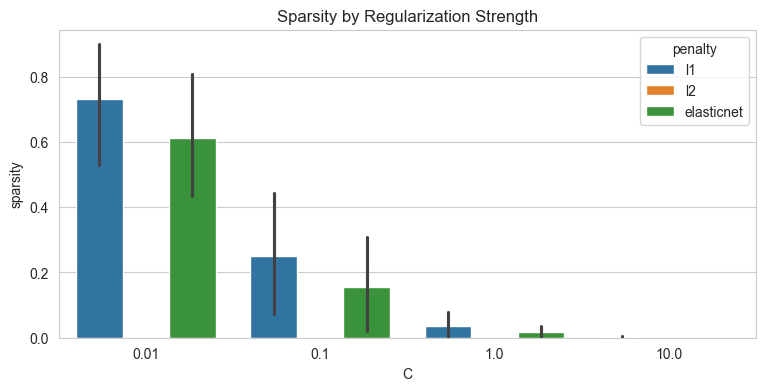

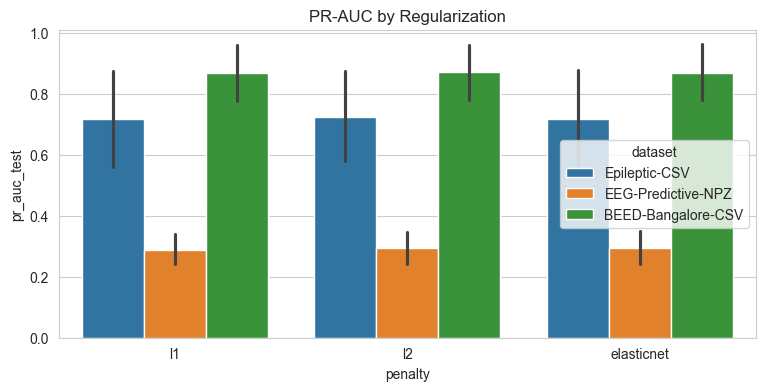

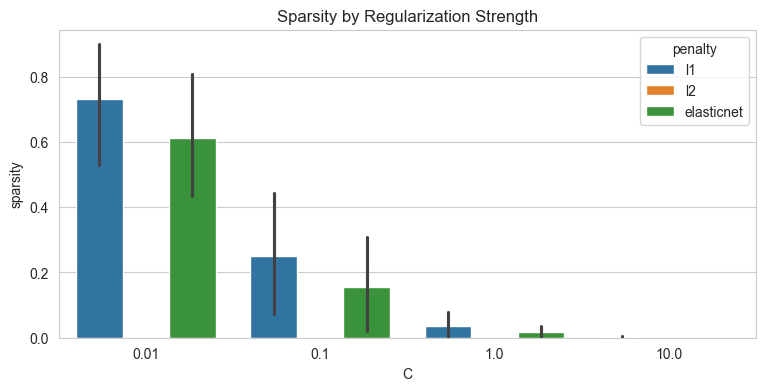

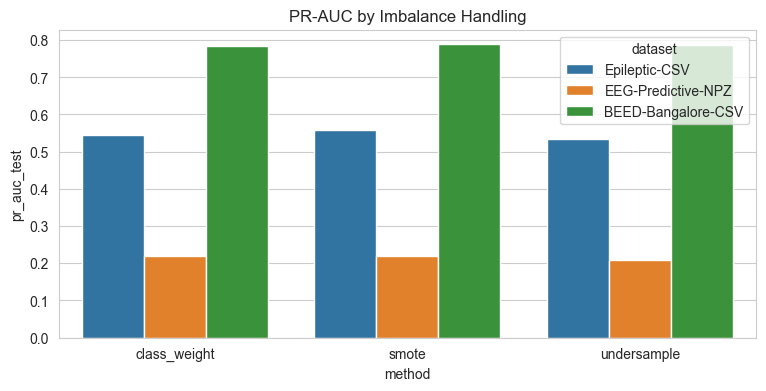

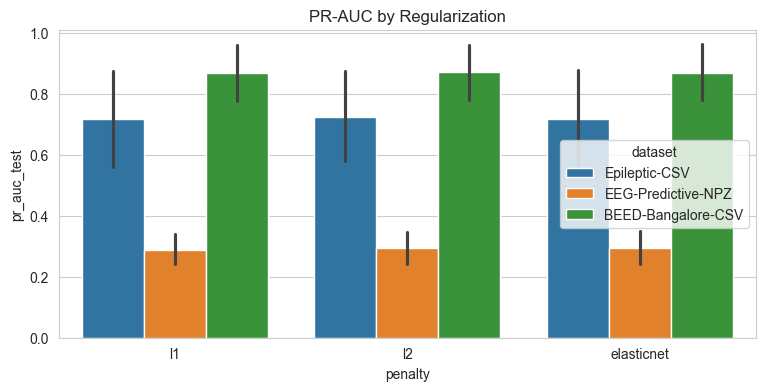

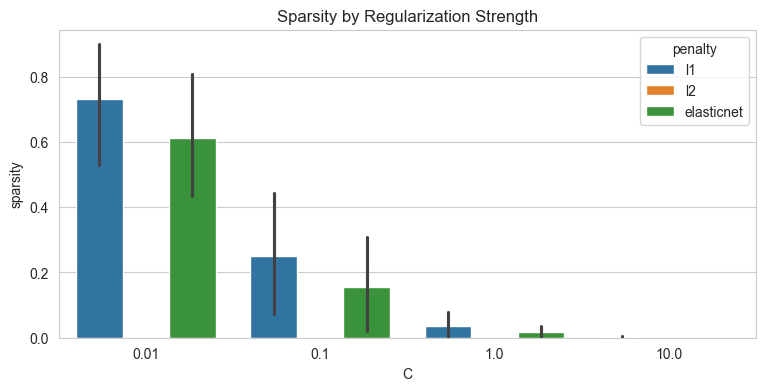

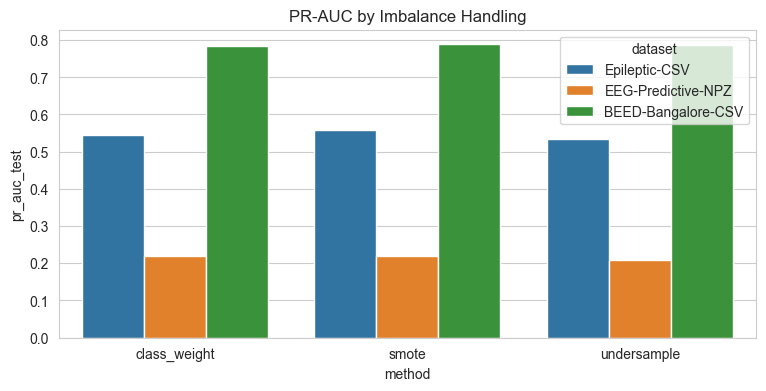

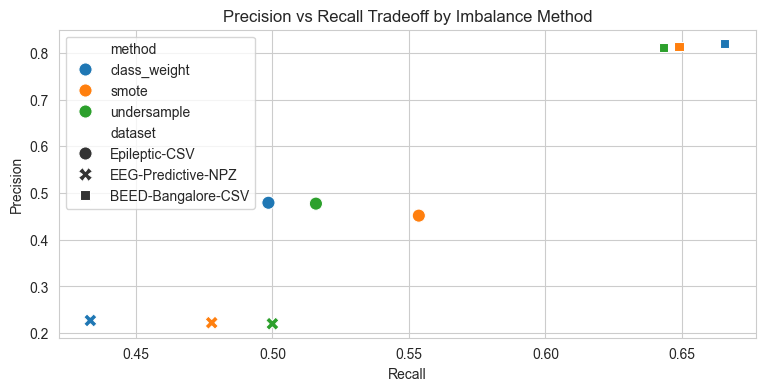

**Best regularization setting per dataset**

,dataset,pipeline,penalty,C,pr_auc_test,sparsity,nonzero_coefs
71,BEED-Bangalore-CSV,B,elasticnet,10.00,0.992874,0.000000,7
22,Epileptic-CSV,B,elasticnet,1.00,0.936005,0.000000,40
44,EEG-Predictive-NPZ,B,elasticnet,0.01,0.375633,0.645161,11


**Best imbalance handling method per dataset**

,dataset,method,pr_auc_test,precision_test,recall_test,f1_test,accuracy_test
7,BEED-Bangalore-CSV,smote,0.788933,0.813370,0.648889,0.721879,0.625000
1,Epileptic-CSV,smote,0.558088,0.451537,0.553623,0.497396,0.776232
3,EEG-Predictive-NPZ,class_weight,0.219631,0.227184,0.433333,0.298089,0.556718


In [15]:
plt.figure(figsize=(9, 4))
sns.barplot(data=reg_df, x='penalty', y='pr_auc_test', hue='dataset')
plt.title('PR-AUC by Regularization')
plt.show()

plt.figure(figsize=(9, 4))
sns.barplot(data=reg_df, x='C', y='sparsity', hue='penalty')
plt.title('Sparsity by Regularization Strength')
plt.show()

plt.figure(figsize=(9, 4))
sns.barplot(data=imbalance_df, x='method', y='pr_auc_test', hue='dataset')
plt.title('PR-AUC by Imbalance Handling')
plt.show()

plt.figure(figsize=(9, 4))
sns.scatterplot(data=imbalance_df, x='recall_test', y='precision_test', hue='method', style='dataset', s=90)
plt.title('Precision vs Recall Tradeoff by Imbalance Method')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

best_imbalance_by_dataset = (
    imbalance_df.sort_values('pr_auc_test', ascending=False)
    .groupby('dataset')
    .head(1)
    [['dataset', 'method', 'pr_auc_test', 'precision_test', 'recall_test', 'f1_test', 'accuracy_test']]
)

display(Markdown('**Best regularization setting per dataset**'))
display(best_reg_by_dataset[['dataset', 'pipeline', 'penalty', 'C', 'pr_auc_test', 'sparsity', 'nonzero_coefs']])
display(Markdown('**Best imbalance handling method per dataset**'))
display(best_imbalance_by_dataset)


## Comparative Analysis (Required Questions)

- **Does preprocessing order affect results?** Yes. The `order_effect` table compares Pipeline A and Pipeline B using test PR-AUC. A positive `B_minus_A_pr_auc` means feature extraction → scaling → PCA performed better; a negative value means normalization → noise clipping → feature selection performed better. This directly shows that changing preprocessing order changes the final decision boundary and generalization score.

- **Which regularization generalizes best across datasets?** The `best_reg_by_dataset` table gives the strongest model for each dataset, while `reg_stability` compares mean PR-AUC and standard deviation across all datasets/pipelines. The best penalty is not universal; it depends on the dataset dimensionality and the preprocessing pipeline.

- **Does Elastic Net consistently outperform L1/L2?** No. Elastic Net is included at several strengths (`C = 0.01, 0.1, 1, 10`), but the best-per-dataset table shows whether it actually wins. If L1 or L2 appears as the best row for a dataset, then Elastic Net did not consistently outperform the simpler penalties.

- **How does imbalance handling interact with regularization?** The imbalance table now includes precision and recall, not only F1/accuracy/PR-AUC. This matters because SMOTE, undersampling, and class weighting usually increase recall by predicting more positive cases, but this can reduce precision. The precision-recall scatter plot makes that tradeoff visible.


## Conclusions

This study shows that preprocessing order has a strong effect on seizure/EEG classification performance. Pipeline A keeps more direct signal information through scaling, clipping, and feature selection, while Pipeline B changes the representation through feature extraction and PCA. The better pipeline changes by dataset, which supports the main research idea that preprocessing decisions affect generalization.

The regularization study shows that no single penalty is always best. L1 can act as feature selection when regularization is strong enough, L2 is usually stable because it shrinks all coefficients smoothly, and Elastic Net is a useful compromise but does not consistently beat both L1 and L2. The sparsity table is important because it shows how many features each model actually uses.

Class imbalance handling changes the precision-recall balance. Class weighting, SMOTE, and undersampling can improve recall for the seizure/positive class, but they may lower precision or accuracy. For imbalanced seizure prediction, PR-AUC, precision, recall, and F1 are more informative than accuracy alone.

BEED Bangalore provides a third epilepsy dataset with labeled EEG features, enabling consistent comparison of preprocessing order, regularization, and imbalance handling across three seizure-related datasets.